slide 1.
Our MQP attempts to generate meaningful connections between Machine Learning and Dynamical Systems/Chaos Theory. 


slide 2.

In order to understand our MQP and it's results we must first establish a basic understanding of dynamical systems as they apply to MLPs and machine learning architectures. 

A dynamical system describes how a state evolves in time according to a rule:

$f(x_t)= x_{t+1}$ 

Dynamical systems exist in both discrete and continuous forms. Because we however, are limited to computers we will only consider discrete time dynamical systems or "iterative maps". 

slide 3.
In many ways Neural Networks Exist as Iterative Maps. RNNs are dynamical systems, evolving an intial state until equilibrium is achieved. ResNets are discrete-time dynamical systems and approximate ODE flows. It is even possible to show how any aribitrary MLP defines an iterative map in the appropriate space.

slide 4.
Analyzing the iterative denoising map.

For our research we focus on analyzing the iterative map created by repeatedly applying a Denoising Auto Encoder(DAE) to its own outputs. The DAE consists of a fully connected(MLP) architecture, and is trained to denoise MNIST images with gaussian noise applied. The dynamical system emerges when we take the models output and recursively feed it back in as input.

Typically, a DAE performs a single mapping $f(x) \rightarrow \hat{y}$ 

we instead treat it as the recurance $f(x_t) \rightarrow x_{t+1}$

Producing a discrete time dynamical system.

slide 5.
Now that we've turned our DAE into an iterative map what do we get? 

Iterative maps have many interesting characteristics that tell us something about the system they create.
1. Fixed points: $f(x^*) = x^*$. Trajectories may flow twoards, away from or sit near fixed points. 
2. Attractors: Sets twoards which trajectories in a region (basin) converge over time. 
3. Contraction and Expansion: A map may push states closer together, further apart, or a mix of both. This determines whether the system stabilizes, diverges or becomes chaotic.

In the abstract sense this tells us the structure of the system and the important behaviors/regions within it. That sounds cool but really doesn't actually mean anything without context. So what could all of this actually tell us in practice?

By evaluting the DAE as an iterative map we ask what deep function has the network learned? 

slide 6. 
Approximating the manifold. 
The MNIST dataset does not occupy the full 784 pixel space. Rather, it occupies a low-dimensional submanifold of the space. Autoencoders are especially relevant here as they learn to compress higher-dimensional data to a meaningful representation in a lowerdimensional space. A DAE learns to map off-manifold noisy inputs toward the data manifold. Iterating the DAE allows us to observe how the model understands the shape and structure of this manifold. 

- Does off manifold data get pulled to the manifold and stay there over time? 
- Are certain regions of the manifold attracting? Many trajectories converging to a few small regions/points could reveal meaningful structures that exist in the data and were unintentionally learned by the network. 
- If trajectories are pushed apart what boundaries cause them to seperate?


100%|██████████| 9.91M/9.91M [00:00<00:00, 33.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.40MB/s]


torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])


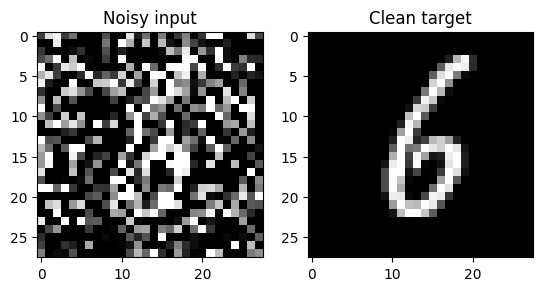

In [ ]:
import torch
import torchvision 
import matplotlib.pyplot as plt
import sklearn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

class NoisyMNIST(Dataset):
    def __init__(self, mnist_dataset, noise_factor=0.01):
        self.mnist = mnist_dataset
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.mnist)
    
    def add_noise(self, img, sigma =.23):
        """
        Add zero-mean Gaussian noise to an MNIST image tensor in [0, 1].
        
        Args:
            img (torch.Tensor): Input image tensor, shape (C, H, W), values in [0, 1].
            sigma (float): Standard deviation of the Gaussian noise.
        
        Returns:
            torch.Tensor: Noisy image, same shape, clamped to [0, 1].
        """
        # Generate zero-mean Gaussian noise
        noise = torch.randn_like(img) * sigma
        
        # Add noise symmetrically (can brighten or darken)
        noisy = img + noise
        # Clamp to valid range
        noisy = torch.clamp(noisy, 0., 1.)
        return noisy
    

    def __getitem__(self, idx):
        # y = clean image (target)
        y, label = self.mnist[idx]
        # x = noisy image (input)
        x = self.add_noise(y, sigma=self.noise_factor)
        return x, y  # return noisy-clean pair

batch_size = 128

train_loader = DataLoader(
    NoisyMNIST(train_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    NoisyMNIST(test_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=False
)

x, y = next(iter(train_loader))
print(x.shape, y.shape)
# -> torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])

plt.subplot(1,2,1)
plt.title("Noisy input")
plt.imshow(x[0][0].detach().cpu(), cmap="gray")
plt.subplot(1,2,2)
plt.title("Clean target")
plt.imshow(y[0][0].detach().cpu(), cmap="gray")
plt.show()

Using device: mps
Epoch [1/10]  Train Loss: 0.0656  Val Loss: 0.0508
Epoch [2/10]  Train Loss: 0.0430  Val Loss: 0.0375
Epoch [3/10]  Train Loss: 0.0357  Val Loss: 0.0336
Epoch [4/10]  Train Loss: 0.0329  Val Loss: 0.0313
Epoch [5/10]  Train Loss: 0.0305  Val Loss: 0.0291
Epoch [6/10]  Train Loss: 0.0287  Val Loss: 0.0276
Epoch [7/10]  Train Loss: 0.0276  Val Loss: 0.0267
Epoch [8/10]  Train Loss: 0.0266  Val Loss: 0.0258
Epoch [9/10]  Train Loss: 0.0259  Val Loss: 0.0251
Epoch [10/10]  Train Loss: 0.0252  Val Loss: 0.0245


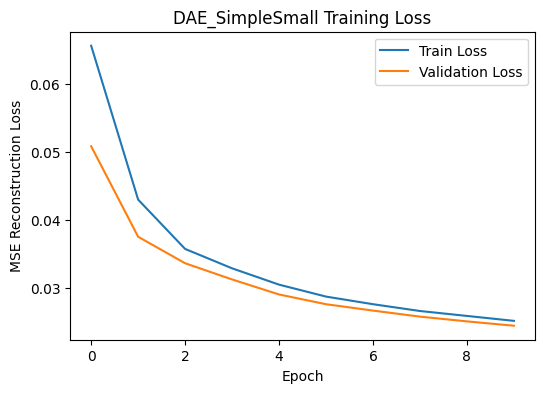

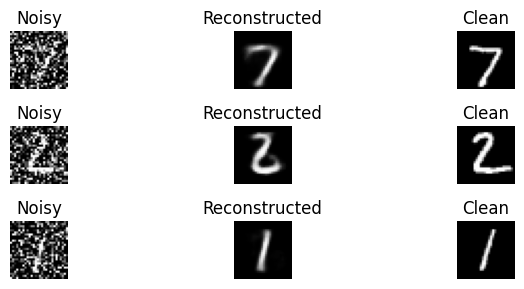

In [ ]:
import torch.nn as nn
class DAE_SimpleSmall(nn.Module):
    """
    Simpler, smaller-capacity DAE for MNIST.
    Uses only Linear + ReLU + Sigmoid; no dropout/BN/skips.
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, latent_dim)      # linear bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE_SimpleSmall(latent_dim=16).to(device)

criterion = nn.MSELoss()  # reconstruction loss (good for Gaussian noise)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Keep epochs logic as-is (adjust if you want)
num_epochs = 10

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Simple early stopping on plateau
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DAE_SimpleSmall Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

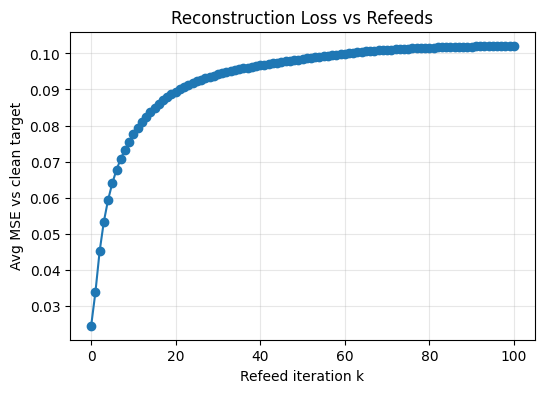

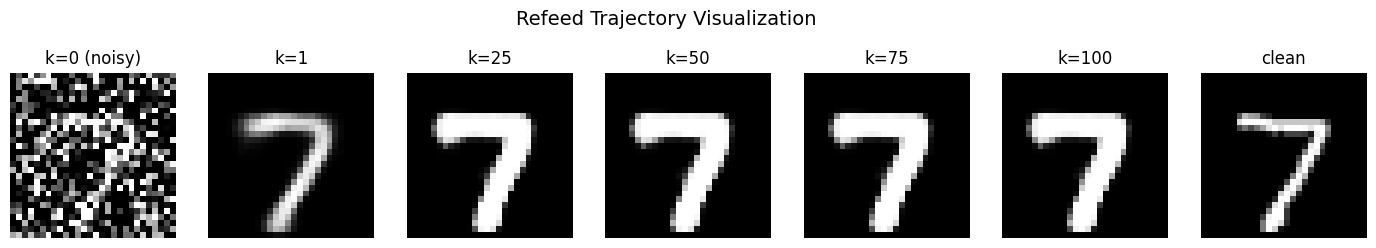

In [21]:
import os
os.makedirs("Photos", exist_ok=True)   # Create folder if not exists

# =====================================================================
# Evaluate refeeds (unchanged except for optional saving)
# =====================================================================
@torch.no_grad()
def evaluate_refeeds(model, loader, criterion, num_refeeds=5, device="cpu"):
    """
    Compute average reconstruction loss on the test set after k refeeds.
    k=0: one forward pass from noisy input.
    k=1: model(model(x_noisy)), etc.
    """
    model.eval()
    losses_by_k = [0.0 for _ in range(num_refeeds + 1)]
    count = 0

    for x_noisy, x_clean in loader:
        x_noisy = x_noisy.to(device)
        x_clean = x_clean.to(device)

        xk = x_noisy.clone()

        for k in range(num_refeeds + 1):
            out = model(xk)
            loss = criterion(out, x_clean)

            losses_by_k[k] += loss.item() * x_noisy.size(0)
            xk = out

        count += x_noisy.size(0)

    losses_by_k = [L / count for L in losses_by_k]
    return losses_by_k


# =====================================================================
# Run and plot loss curve, saving to Photos/
# =====================================================================
num_refeeds = 100
refeed_losses = evaluate_refeeds(model, test_loader, criterion, num_refeeds, device=device)

plt.figure(figsize=(6,4))
plt.plot(range(num_refeeds + 1), refeed_losses, marker="o")
plt.xlabel("Refeed iteration k")
plt.ylabel("Avg MSE vs clean target")
plt.title("Reconstruction Loss vs Refeeds")
plt.grid(True, alpha=0.3)

plt.savefig("Photos/refeed_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


# =====================================================================
# Visualization of specific sample trajectory with correct k-labels
# =====================================================================
@torch.no_grad()
def visualize_refeeds(model, loader, device="cpu", num_refeeds=10, idx=0):

    model.eval()
    x_noisy, x_clean = next(iter(loader))
    x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

    # State variables
    xk = x_noisy.clone()

    # Always show k=0 (initial noisy input)
    imgs = [(x_noisy[idx:idx+1].cpu(), "k=0 (noisy)")]

    # Select ks to visualize: 1, 25%, 50%, 75%, 100%
    ks_to_show = sorted(set([
        1,
        max(1, round(num_refeeds * 0.25)),
        max(1, round(num_refeeds * 0.50)),
        max(1, round(num_refeeds * 0.75)),
        num_refeeds
    ]))

    # Iterate through refeeds
    for k in range(1, num_refeeds + 1):
        xk = model(xk)
        if k in ks_to_show:
            imgs.append((xk[idx:idx+1].cpu(), f"k={k}"))

    # Append clean image
    imgs.append((x_clean[idx:idx+1].cpu(), "clean"))

    # Create figure
    plt.figure(figsize=(2.5 * len(imgs), 3))

    for i, (img, title) in enumerate(imgs):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(img[0,0], cmap="gray")
        plt.title(title)
        plt.axis("off")

    plt.suptitle("Refeed Trajectory Visualization", fontsize=14)

    # Save to Photos/
    plt.savefig(f"Photos/sample_refeeds_idx{idx}.png", dpi=300, bbox_inches="tight")
    plt.show()


# Example usage
visualize_refeeds(model, test_loader, device=device, num_refeeds=num_refeeds, idx=0)

In [11]:
# -------------------------------------------------------
# Compute epsilon based on average nearest-neighbor distance
# within each digit class in the MNIST test set
# -------------------------------------------------------
@torch.no_grad()
def compute_epsilon_from_nn_test(device="cpu"):
    

    # Load clean MNIST TEST set with labels
    transform = transforms.Compose([transforms.ToTensor()])
    clean_test = torchvision.datasets.MNIST(
        root=".", train=False, download=True, transform=transform
    )

    # Group flattened clean images by class
    class_groups = {k: [] for k in range(10)}
    for img, label in clean_test:
        img = img.to(device)
        class_groups[label].append(img.view(-1))  # flatten to 784 dims

    # Compute per-class average nearest-neighbor distances
    avg_nn_dists = {}

    for digit in range(10):
        X = torch.stack(class_groups[digit])   # [n_c, 784]
        n_c = X.size(0)

        # Full pairwise distance matrix for this class
        dist_matrix = torch.cdist(X, X, p=2)   # [n_c, n_c]
        dist_matrix.fill_diagonal_(float("inf"))

        # For each sample, find nearest same-class sample
        nn_dists, _ = dist_matrix.min(dim=1)

        # Average NN distance for this digit
        avg_nn_dists[digit] = nn_dists.mean().item()

    # Global epsilon = average over all classes
    epsilon_state = sum(avg_nn_dists.values()) / 10.0

    return avg_nn_dists, epsilon_state


# Run and print results
avg_nn_dists, epsilon_state = compute_epsilon_from_nn_test(device=device)

print("\nAverage nearest-neighbor distance per digit class:")
for d in range(10):
    print(f"Digit {d}: {avg_nn_dists[d]:.5f}")

print("\nFinal epsilon_state (mean of class NN radii):", epsilon_state)

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 11.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.00MB/s]



Average nearest-neighbor distance per digit class:
Digit 0: 4.89065
Digit 1: 2.16429
Digit 2: 5.57780
Digit 3: 5.26922
Digit 4: 4.77385
Digit 5: 5.32689
Digit 6: 4.72230
Digit 7: 4.13368
Digit 8: 5.53710
Digit 9: 4.38774

Final epsilon_state (mean of class NN radii): 4.6783514499664305


Generating trajectories


Processing batches for trajectories: 100%|██████████| 79/79 [00:15<00:00,  5.03it/s]



num_steps = 300
Fraction converged before k=240: 0.9994
Latest convergence index (among converged): 238
Average convergence index (among converged): 51.26


Processing batches for trajectories: 100%|██████████| 79/79 [00:24<00:00,  3.23it/s]


num_steps = 500
Fraction converged before k=400: 1.0000
Latest convergence index (among converged): 307
Average convergence index (among converged): 51.32


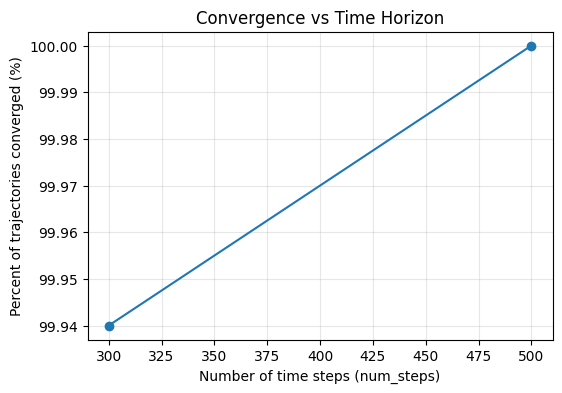

Processing batches for trajectories: 100%|██████████| 79/79 [00:24<00:00,  3.26it/s]


first_states shape: torch.Size([10000, 1, 28, 28])
final_states shape: torch.Size([10000, 1, 28, 28])
halt indices shape: (10000,)
z_first shape: torch.Size([10000, 16])
z_final shape: torch.Size([10000, 16])


In [14]:
from tqdm import tqdm
def find_halt(steps, eps):
    """
    steps: list of per-step distances d_t = ||x_{t+1} - x_t||
    eps: tolerance on total movement of the tail

    Returns earliest index i such that sum_{t=i}^{T-1} steps[t] <= eps.
    """
    hlt_indx = len(steps)
    suffix_sum = 0.0
    for i in range(len(steps)-1, -1, -1):
        suffix_sum += steps[i]
        if suffix_sum <= eps:
            hlt_indx = i
        else:
            break
    return hlt_indx

@torch.no_grad()
def find_attractor_indices(model, loader, num_steps, eps_state, device="cpu"):
    """
    Unroll num_steps refeeds for each sample.

    For each trajectory:
      - Compute per-step distances d_t = ||x_{t+1} - x_t||.
      - Compute halting index via tail sum <= eps_state.
      - Save x_1 (after first pass) and x_T (after num_steps passes).

    Returns:
      all_halt_indices: np.array shape [N]
      first_states:     torch.Tensor [N, 1, 28, 28] (after 1 pass)
      final_states:     torch.Tensor [N, 1, 28, 28] (after num_steps)
    """
    model.eval()
    all_halt_indices = []
    first_states_batches = []
    final_states_batches = []

    for x_noisy, _ in tqdm(loader, desc="Processing batches for trajectories"):
        x_noisy = x_noisy.to(device)
        batch_size = x_noisy.size(0)

        xk = x_noisy
        step_sizes_batch = []

        for t in range(num_steps):
            x_next = model(xk)
            diff = x_next - xk

            d_batch = torch.norm(diff.view(batch_size, -1), p=2, dim=1)
            step_sizes_batch.append(d_batch.unsqueeze(1))

            # Save after first pass
            if t == 0:
                first_states_batches.append(x_next.cpu())

            xk = x_next

        final_states_batches.append(xk.cpu())
        step_sizes_batch = torch.cat(step_sizes_batch, dim=1)  # [B, num_steps]

        for b in range(batch_size):
            d_row = step_sizes_batch[b].tolist()
            halt_idx = find_halt(d_row, eps_state)
            all_halt_indices.append(halt_idx)

    first_states = torch.cat(first_states_batches, dim=0)   # [N, 1, 28, 28]
    final_states = torch.cat(final_states_batches, dim=0)   # [N, 1, 28, 28]
    all_halt_indices = np.array(all_halt_indices, dtype=np.int64)

    return all_halt_indices, first_states, final_states

def test_halting(step_list, tolerance, loader):
    """
    For different trajectory lengths (time horizons) in step_list,
    compute the fraction of trajectories whose halt index occurs
    before 0.8 * num_steps.
    """
    converged_fracs = []

    print("Generating trajectories")
    for num_steps in step_list:
        all_halt_indices, _, _ = find_attractor_indices(
            model,
            loader,
            num_steps=num_steps,
            eps_state=tolerance,
            device=device,
        )

        halt_arr = np.array(all_halt_indices)
        total_samples = halt_arr.shape[0]

        cutoff = int(num_steps * 0.8)
        converged_mask = halt_arr < cutoff
        num_converged = int(converged_mask.sum())
        frac_converged = num_converged / total_samples
        converged_fracs.append(frac_converged)

        print(f"\nnum_steps = {num_steps}")
        print(f"Fraction converged before k={cutoff}: {frac_converged:.4f}")

        if num_converged > 0:
            latest = halt_arr[converged_mask].max()
            avg = halt_arr[converged_mask].mean()
            print(f"Latest convergence index (among converged): {latest}")
            print(f"Average convergence index (among converged): {avg:.2f}")
        else:
            print("No trajectories converged under this tolerance.")

    if len(step_list) > 1:
        plt.figure(figsize=(6,4))
        plt.plot(step_list, np.array(converged_fracs) * 100.0, marker="o")
        plt.xlabel("Number of time steps (num_steps)")
        plt.ylabel("Percent of trajectories converged (%)")
        plt.title("Convergence vs Time Horizon")
        plt.grid(True, alpha=0.3)
        plt.show()

# --------------------------
# 6. Example: run halting analysis + get first/final states for clustering
# --------------------------

epsilon_state = 0.5   # tolerance on tail movement; tune this hyperparameter
step_list = [300, 500]

test_halting(step_list=step_list, tolerance=epsilon_state, loader=test_loader)

# If you want specific trajectories + states for clustering, call once with a chosen num_steps:
num_steps_for_clustering = 500
all_halt_indices, first_states, final_states = find_attractor_indices(
    model,
    test_loader,
    num_steps=num_steps_for_clustering,
    eps_state=epsilon_state,
    device=device,
)

print("first_states shape:", first_states.shape)
print("final_states shape:", final_states.shape)
print("halt indices shape:", all_halt_indices.shape)

# Example: encode latents for clustering later
with torch.no_grad():
    z_first = model.encoder(first_states.to(device)).cpu()   # [N, 16]
    z_final = model.encoder(final_states.to(device)).cpu()   # [N, 16]

print("z_first shape:", z_first.shape)
print("z_final shape:", z_final.shape)

z_first shape: (10000, 16)
[z_first] k= 4, silhouette=0.1924
[z_first] k= 5, silhouette=0.1814
[z_first] k= 6, silhouette=0.1945
[z_first] k= 7, silhouette=0.2019
[z_first] k= 8, silhouette=0.1999
[z_first] k= 9, silhouette=0.1989
[z_first] k=10, silhouette=0.1996
[z_first] k=11, silhouette=0.2043
[z_first] k=12, silhouette=0.2036
[z_first] k=13, silhouette=0.2080
[z_first] k=14, silhouette=0.2100
[z_first] k=15, silhouette=0.2060
[z_first] k=16, silhouette=0.2060
[z_first] k=17, silhouette=0.2045
[z_first] k=18, silhouette=0.2044
[z_first] k=19, silhouette=0.2015
[z_first] k=20, silhouette=0.1989
[z_first] k=21, silhouette=0.1930
[z_first] k=22, silhouette=0.1933
[z_first] k=23, silhouette=0.1930
[z_first] k=24, silhouette=0.1918
[z_first] k=25, silhouette=0.1937
[z_first] k=26, silhouette=0.1935
[z_first] k=27, silhouette=0.1942
[z_first] k=28, silhouette=0.1947
[z_first] k=29, silhouette=0.1900
[z_first] k=30, silhouette=0.1865
[z_first] k=31, silhouette=0.1868
[z_first] k=32, silho

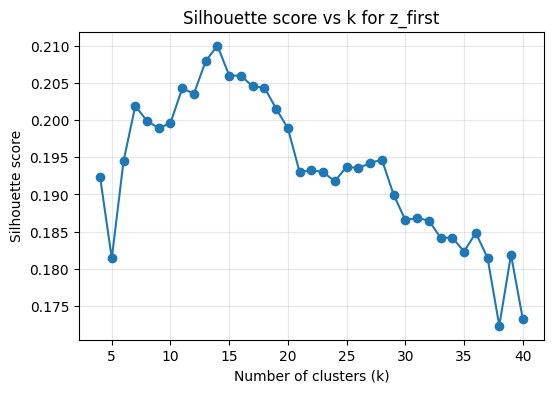

Saved silhouette plot → Photos/z_first_silhouette.png

Best k for z_first = 14 (silhouette=0.2100)


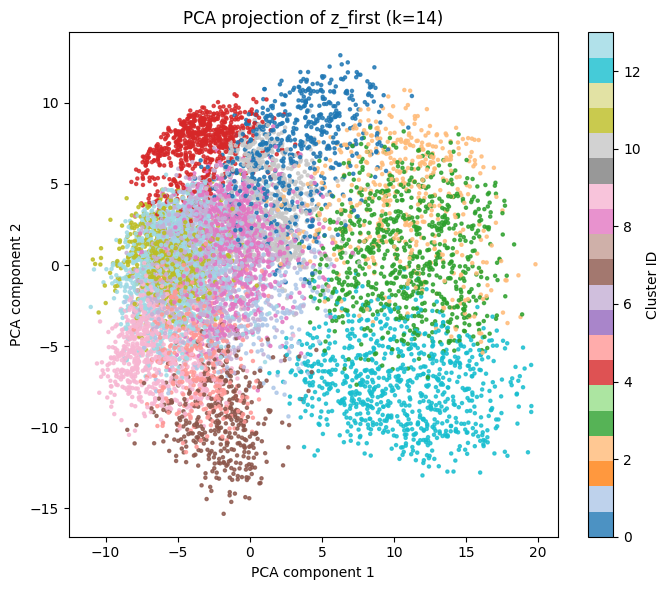

Saved PCA cluster plot → Photos/z_first_pca_k14.png
z_final shape: (10000, 16)
[z_final] k= 4, silhouette=0.4400
[z_final] k= 5, silhouette=0.5024
[z_final] k= 6, silhouette=0.5679
[z_final] k= 7, silhouette=0.6205
[z_final] k= 8, silhouette=0.6671
[z_final] k= 9, silhouette=0.6965
[z_final] k=10, silhouette=0.7290
[z_final] k=11, silhouette=0.7790
[z_final] k=12, silhouette=0.7995
[z_final] k=13, silhouette=0.8192
[z_final] k=14, silhouette=0.8485
[z_final] k=15, silhouette=0.8640
[z_final] k=16, silhouette=0.8728
[z_final] k=17, silhouette=0.9069
[z_final] k=18, silhouette=0.9180
[z_final] k=19, silhouette=0.9267
[z_final] k=20, silhouette=0.9381
[z_final] k=21, silhouette=0.9580
[z_final] k=22, silhouette=0.9683
[z_final] k=23, silhouette=0.9712
[z_final] k=24, silhouette=0.9739
[z_final] k=25, silhouette=0.9780
[z_final] k=26, silhouette=0.9807
[z_final] k=27, silhouette=0.9844
[z_final] k=28, silhouette=0.9885
[z_final] k=29, silhouette=0.9903
[z_final] k=30, silhouette=0.9908
[z_

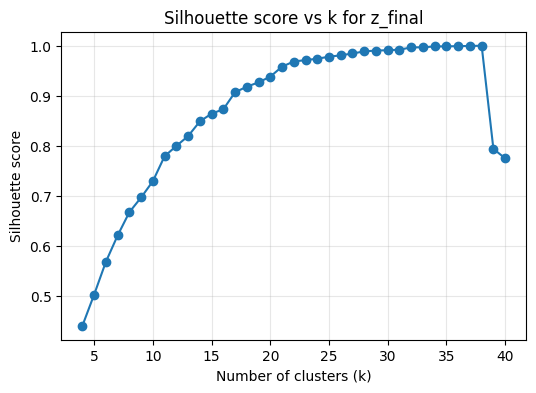

Saved silhouette plot → Photos/z_final_silhouette.png

Best k for z_final = 38 (silhouette=0.9999)


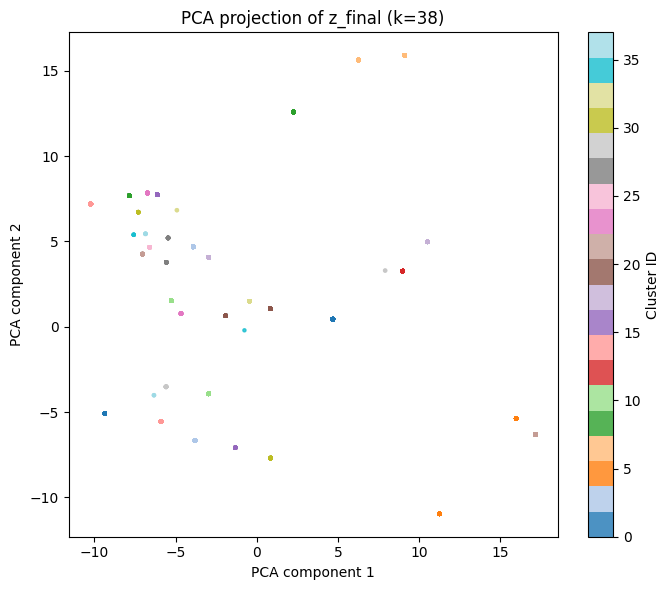

Saved PCA cluster plot → Photos/z_final_pca_k38.png


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

def cluster_and_plot_latents(z_tensor, name="z", k_min=4, k_max=40):
    """
    z_tensor: torch.Tensor of shape [N, D]
    name: string label ("z_first" or "z_final")
    Saves:
        Photos/{name}_silhouette.png
        Photos/{name}_pca_k<best_k>.png
    """
    z_np = z_tensor.cpu().numpy()
    print(f"{name} shape:", z_np.shape)

    k_values = list(range(k_min, k_max + 1))
    sil_scores = []

    # ============================================================
    # Compute silhouette scores for all k
    # ============================================================
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = kmeans.fit_predict(z_np)
        score = silhouette_score(z_np, labels)
        sil_scores.append(score)
        print(f"[{name}] k={k:2d}, silhouette={score:.4f}")

    # ============================================================
    # Plot silhouette vs k
    # ============================================================
    plt.figure(figsize=(6,4))
    plt.plot(k_values, sil_scores, marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title(f"Silhouette score vs k for {name}")
    plt.grid(True, alpha=0.3)

    # Save silhouette plot
    sil_path = f"Photos/{name}_silhouette.png"
    plt.savefig(sil_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved silhouette plot → {sil_path}")

    # ============================================================
    # Find best k
    # ============================================================
    best_idx = int(np.argmax(sil_scores))
    best_k = k_values[best_idx]
    best_score = sil_scores[best_idx]
    print(f"\nBest k for {name} = {best_k} (silhouette={best_score:.4f})")

    # Refit with best k
    best_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
    labels = best_kmeans.fit_predict(z_np)

    # ============================================================
    # PCA 2D projection
    # ============================================================
    pca = PCA(n_components=2, random_state=42)
    z_2d = pca.fit_transform(z_np)

    plt.figure(figsize=(7,6))
    scatter = plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=labels,
        cmap="tab20",
        s=5,
        alpha=0.8
    )
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title(f"PCA projection of {name} (k={best_k})")
    plt.colorbar(scatter, label="Cluster ID")
    plt.tight_layout()

    # Save PCA plot
    pca_path = f"Photos/{name}_pca_k{best_k}.png"
    plt.savefig(pca_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved PCA cluster plot → {pca_path}")

    # Return results
    return {
        "k_values": k_values,
        "sil_scores": sil_scores,
        "best_k": best_k,
        "best_score": best_score,
        "labels": labels,
        "z_2d": z_2d,
    }
res_first = cluster_and_plot_latents(z_first, name="z_first")
res_final = cluster_and_plot_latents(z_final, name="z_final")